# Introduction to Rasterio

Rasterio is a Python library used for reading and writing geospatial raster data. It builds on top of the GDAL (Geospatial Data Abstraction Library) and provides a more Pythonic interface for working with raster datasets. Rasterio enables efficient and convenient access to raster data and supports a wide range of formats.

## Key Features

- **Read and Write Raster Data**: Handle multiple raster formats, including GeoTIFF, PNG, JPEG, and more.
- **CRS Handling**: Supports coordinate reference systems (CRS) for accurate geospatial data representation.
- **Metadata Access**: Easily access and manipulate metadata associated with raster datasets.
- **Data Processing**: Perform raster data manipulation, such as cropping, masking, reprojecting, and resampling.
- **Integration with NumPy**: Leverage NumPy arrays for raster data analysis and processing.


#### Opening a Raster File
To open a raster file and read its metadata and data, use the following code:

In [16]:
import rasterio

# Open the raster file
RASTER_FILE_PATH = 'raster_files/QC_2018_2023.tif'
with rasterio.open(RASTER_FILE_PATH) as src:
    print(src.profile)  # Print metadata
    data = src.read(1)  # Read the first band

# Display the data array
print(data)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 496, 'height': 319, 'count': 5, 'crs': CRS.from_epsg(4326), 'transform': Affine(8.983152841195215e-05, 0.0, 121.03145553387772,
       0.0, -8.983152841195215e-05, 14.6650868447796), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}
[[1337.5    1374.6666 1370.5    ... 1427.5    1427.5    1339.6   ]
 [1224.5    1044.     1997.3334 ... 1614.     1412.5    1523.    ]
 [1261.6    1710.     2876.6667 ... 1329.3334 1158.5    1286.    ]
 ...
 [ 709.5     964.     1151.5    ...  819.      754.75    565.6667]
 [ 856.      921.     1036.     ...  920.3333  754.8333  546.    ]
 [ 979.6667 1075.     1148.     ... 1046.      765.3333  516.    ]]


#### Reading data from a raster file and writing to a new file can be done as follows:

In [17]:
from rasterio.plot import show
import numpy as np

# Open the source raster file
with rasterio.open(RASTER_FILE_PATH) as src:
    data = src.read(1)  # Read the first band


    # Perform some processing on the data (e.g., multiply by 2)
    processed_data = data * 2

    # Define the profile for the new raster file
    profile = src.profile
    profile.update(dtype=rasterio.float32)

    EXPORT_RASTER_FILE_PATH = "raster_files/exported_rasterfile.tif"
    # Write the processed data to a new raster file
    with rasterio.open(EXPORT_RASTER_FILE_PATH, "w", **profile) as dst:
        dst.write(processed_data.astype(rasterio.float32), 1)

print(processed_data)

[[2675.     2749.3333 2741.     ... 2855.     2855.     2679.2   ]
 [2449.     2088.     3994.6667 ... 3228.     2825.     3046.    ]
 [2523.2    3420.     5753.3335 ... 2658.6667 2317.     2572.    ]
 ...
 [1419.     1928.     2303.     ... 1638.     1509.5    1131.3334]
 [1712.     1842.     2072.     ... 1840.6666 1509.6666 1092.    ]
 [1959.3334 2150.     2296.     ... 2092.     1530.6666 1032.    ]]


#### Plotting Raster Data

Rasterio integrates with matplotlib for easy plotting of raster data:

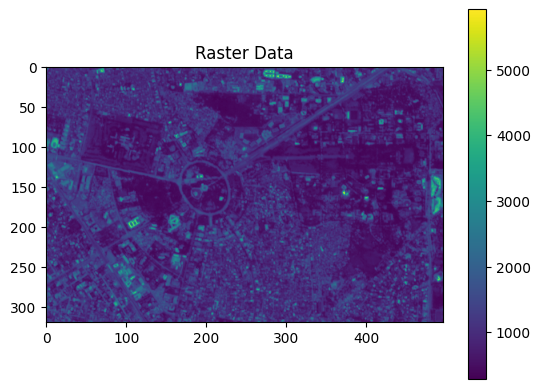

In [7]:
import matplotlib.pyplot as plt

# Open the raster file
with rasterio.open(RASTER_FILE_PATH) as src:
    data = src.read(1)  # Read the first band

    # Plot the data
    plt.imshow(data, cmap='viridis')
    plt.colorbar()
    plt.title('Raster Data')
    plt.show()

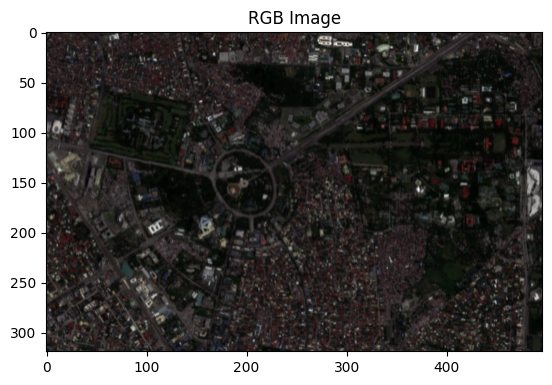

In [13]:
# Open the raster file
with rasterio.open(RASTER_FILE_PATH) as src:
    # Read the red, green, and blue bands
    red = src.read(3)
    green = src.read(2)
    blue = src.read(1)

    # Normalize the bands to the range 0-255
    def normalize(array):
        array_min, array_max = array.min(), array.max()
        return ((array - array_min) / (array_max - array_min) * 255).astype(np.uint8)

    red = normalize(red)
    green = normalize(green)
    blue = normalize(blue)

    # Stack the bands into a single 3D array
    rgb = np.dstack((red, green, blue))

# Display the RGB image
plt.imshow(rgb)
plt.title("RGB Image")
plt.show()